# 05 · Démarrage LSA SAF pour l'ETP

Ce notebook montre comment télécharger l'ETP avec la source **LSA SAF** dans `agrometflow` selon deux approches :
- **sur une liste de points** avec des coordonnées **(lon, lat)** ;
- **sur une bbox** pour produire un NetCDF annuel déjà découpé.

Remarques importantes :
- ce notebook nécessite une connexion internet fonctionnelle ;
- l'accès au serveur LSA SAF est protégé : il faut disposer d'un compte et de ses identifiants ;
- dans l'implémentation actuelle du package, la variable utilisateur `ETP` est alimentée par le produit `mdmetv3`, dont le champ source est `ET` côté LSA SAF.


## Préparation

On sépare les sorties des deux cas d'usage :
- `training_outputs/lsasaf_points/` pour l'extraction sur points ;
- `training_outputs/lsasaf_bbox/` pour la bbox.


In [ ]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

from agrometflow.climate.lsasaf import (
    LSASAFDownloader,
    build_points_csv_path,
    build_yearly_nc_path,
)

points_output_dir = Path("training_outputs/lsasaf_points")
bbox_output_dir = Path("training_outputs/lsasaf_bbox")
points_output_dir.mkdir(parents=True, exist_ok=True)
bbox_output_dir.mkdir(parents=True, exist_ok=True)

username = "ahmcyr"
password = "lsasaf2026"

if not username or not password:
    raise ValueError(
        "Définir les variables d'environnement LSASAF_USERNAME et LSASAF_PASSWORD avant d'exécuter ce notebook."
    )

variables = [("ET", "ETP")]


/home/midingoyi/miniforge3/envs/agrometflow/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cas 1 - Télécharger l'ETP sur une liste de points

On utilise ici deux points de démonstration au Cameroun.

Convention importante :
- l'ordre des coordonnées est **(lon, lat)**.


In [2]:
points = [
    (11.52, 3.87),   # Yaoundé (lon, lat)
    (13.40, 9.30),   # Garoua  (lon, lat)
]

points


[(11.52, 3.87), (13.4, 9.3)]

In [3]:
dl_points = LSASAFDownloader(
    verbose=True,
    log_file=points_output_dir / "lsasaf_points.log",
)

dl_points.download(
    start_date="2021-01-01",
    end_date="2021-12-31",
    variables=variables,
    points=points,
    output_dir=points_output_dir,
    product="mdmetv3",
    username=username,
    password=password,
    overwrite_points_cache=True,
    force_parallel=True,
    max_workers=4
    
)


[INFO] 2026-04-23 13:40:57 — Downloading LSA SAF product 'mdmetv3' for 365 day(s)
[INFO] 2026-04-23 13:40:57 — BBOX: None
[INFO] 2026-04-23 13:40:57 — Max workers: 4 (notebook mode: True)
[INFO] 2026-04-23 13:40:57 — Points: [(11.52, 3.87), (13.4, 9.3)]
[INFO] 2026-04-23 13:40:57 — Prepared 365 daily request(s)
[INFO] 2026-04-23 13:42:54 — Saved points CSV: training_outputs/lsasaf_points/mdmetv3_20210101_20211231_pt_p11p52_p3p87__pt_p13p40_p9p30.csv


In [4]:
etp_points_df = dl_points.extract(variables=["ETP"])
# add point_id column to etp_points_df
etp_points_df["point_id"] = etp_points_df.apply(
    lambda row: f"point_{row['lon']:.2f}_{row['lat']:.2f}", axis=1
)
etp_points_df.head(10)


,time,lon,lat,ETP,point_id
0,2021-01-01,11.52,3.87,2.998,point_11.52_3.87
1,2021-01-01,13.40,9.30,3.110,point_13.40_9.30
2,2021-01-02,11.52,3.87,2.941,point_11.52_3.87
3,2021-01-02,13.40,9.30,3.089,point_13.40_9.30
4,2021-01-03,11.52,3.87,3.223,point_11.52_3.87
5,2021-01-03,13.40,9.30,3.250,point_13.40_9.30
6,2021-01-04,11.52,3.87,2.875,point_11.52_3.87
7,2021-01-04,13.40,9.30,3.285,point_13.40_9.30
8,2021-01-05,11.52,3.87,3.227,point_11.52_3.87
9,2021-01-05,13.40,9.30,3.183,point_13.40_9.30


### Étape pédagogique 2 - Série journalière par point

On trace la série journalière d'ETP pour comparer rapidement la dynamique saisonnière entre les points.


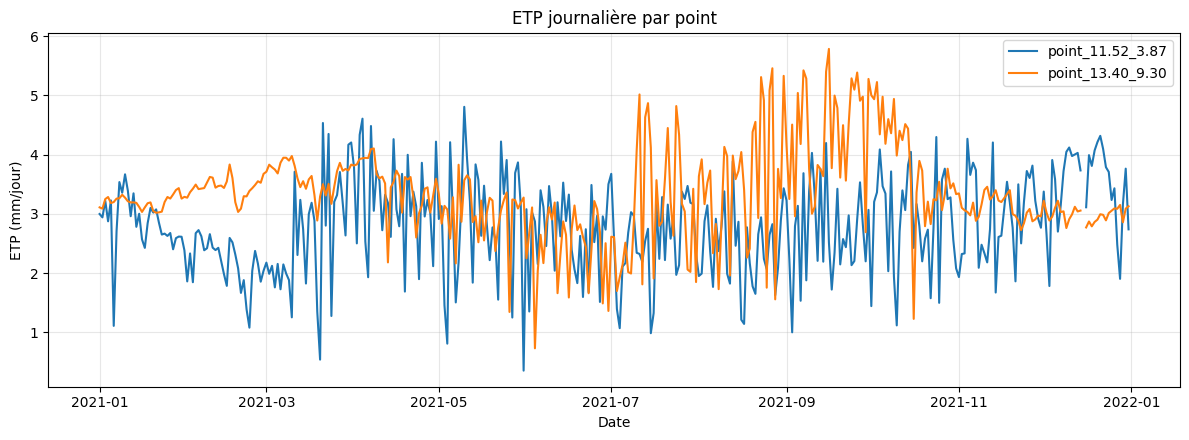

In [5]:
plt.figure(figsize=(12, 4.5))
for point_id, g in etp_points_df.groupby("point_id"):
    plt.plot(g["time"], g["ETP"], linewidth=1.5, label=point_id)

plt.title("ETP journalière par point")
plt.xlabel("Date")
plt.ylabel("ETP (mm/jour)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Étape pédagogique 3 - Totaux mensuels sur points

Pour un bilan hydrique, on passe souvent de la valeur journalière à un **total mensuel**.


In [6]:
# add year and month from time column
etp_points_df["year"] = etp_points_df["time"].dt.year
etp_points_df["month"] = etp_points_df["time"].dt.month
monthly_points = (
    etp_points_df.groupby(["point_id", "year", "month"], as_index=False)
             .agg({"ETP": "sum"})
             .sort_values(["point_id", "year", "month"])
)

monthly_points.head(12)


,point_id,year,month,ETP
0,point_11.52_3.87,2021,1,88.246
1,point_11.52_3.87,2021,2,60.727
2,point_11.52_3.87,2021,3,81.373
3,point_11.52_3.87,2021,4,96.624
4,point_11.52_3.87,2021,5,87.976
5,point_11.52_3.87,2021,6,80.119
6,point_11.52_3.87,2021,7,78.637
7,point_11.52_3.87,2021,8,74.733
8,point_11.52_3.87,2021,9,81.573
9,point_11.52_3.87,2021,10,89.306


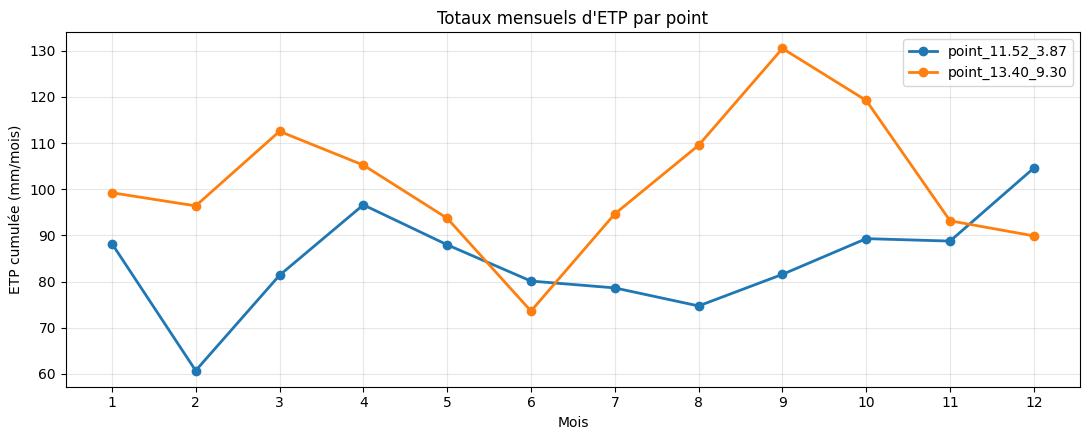

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for point_id, g in monthly_points.groupby("point_id"):
    ax.plot(g["month"], g["ETP"], marker="o", linewidth=2, label=point_id)

ax.set_title("Totaux mensuels d'ETP par point")
ax.set_xlabel("Mois")
ax.set_ylabel("ETP cumulée (mm/mois)")
ax.set_xticks(range(1, 13))
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Cas 2 - Télécharger l'ETP sur une bbox

Ici on télécharge la même variable sur une emprise spatiale couvrant une partie du Cameroun.

Convention de la bbox dans `agrometflow` :
- `[lon_min, lat_min, lon_max, lat_max]`


In [8]:
bbox = [8.0, 2.0, 17.0, 13.0]
bbox


[8.0, 2.0, 17.0, 13.0]

In [9]:
dl_bbox = LSASAFDownloader(
    verbose=True,
    log_file=bbox_output_dir / "lsasaf_bbox.log",
)

dl_bbox.download(
    start_date="2021-01-01",
    end_date="2021-12-31",
    variables=variables,
    bbox=bbox,
    output_dir=bbox_output_dir,
    product="mdmetv3",
    username=username,
    password=password,
)


[INFO] 2026-04-23 13:44:05 — Downloading LSA SAF product 'mdmetv3' for 365 day(s)
[INFO] 2026-04-23 13:44:05 — BBOX: [8.0, 2.0, 17.0, 13.0]
[INFO] 2026-04-23 13:44:05 — Max workers: 1 (notebook mode: True)


TypeError: 'NoneType' object is not iterable

In [ ]:
bbox_nc = build_yearly_nc_path(
    output_dir=bbox_output_dir,
    target_var="ETP",
    product="mdmetv3",
    year=2021,
    bbox=bbox,
)

ds_bbox = xr.open_dataset(bbox_nc)
print("BBox NetCDF:", bbox_nc.name)
ds_bbox


### Étape pédagogique 4 - Vérifier le sous-domaine spatial

On vérifie que le fichier produit est bien limité à la bbox demandée.


In [ ]:
print("Dimensions:", ds_bbox.dims)
print("Longitude:", float(ds_bbox.lon.min()), "->", float(ds_bbox.lon.max()))
print("Latitude:", float(ds_bbox.lat.min()), "->", float(ds_bbox.lat.max()))


### Étape pédagogique 5 - Visualiser un jour d'ETP sur la bbox

On trace une carte simple d'un jour d'exemple.


In [ ]:
day0 = ds_bbox["ETP"].isel(time=0)
plt.figure(figsize=(7, 5))
day0.plot(cmap="YlOrRd")
plt.title("ETP sur la bbox - premier jour disponible")
plt.tight_layout()
plt.show()


### Étape pédagogique 6 - Série moyenne spatiale sur la bbox

On calcule la moyenne spatiale journalière sur toute la bbox, puis on regarde son évolution mensuelle.


In [ ]:
bbox_mean = ds_bbox["ETP"].mean(dim=["lat", "lon"]).to_series().reset_index(name="ETP_mean")
bbox_mean["time"] = pd.to_datetime(bbox_mean["time"])
bbox_mean["month"] = bbox_mean["time"].dt.month

bbox_mean.head()


In [ ]:
monthly_bbox = (
    bbox_mean.groupby("month", as_index=False)
             .agg({"ETP_mean": "mean"})
             .sort_values("month")
)

plt.figure(figsize=(10, 4))
plt.plot(monthly_bbox["month"], monthly_bbox["ETP_mean"], marker="o", linewidth=2, color="darkorange")
plt.title("Cycle mensuel moyen d'ETP sur la bbox")
plt.xlabel("Mois")
plt.ylabel("ETP moyenne (mm/jour)")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## À retenir

- `LSASAFDownloader` permet maintenant deux usages pédagogiques simples : **points** et **bbox** ;
- les coordonnées de points sont fournies en **(lon, lat)** ;
- la bbox suit l'ordre **[lon_min, lat_min, lon_max, lat_max]** ;
- en mode stream, les gros fichiers journaliers ne sont plus conservés en sortie ;
- les résultats utiles restent : un **CSV** pour `points` et un **NetCDF annuel découpé** pour `bbox`.
